In [ ]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

# First try common location
candidate = drive_root / "image-captioning"

if candidate.exists():
    project_dir = candidate
else:
    # Search recursively for a folder named image-captioning with src/train.py
    matches = []
    for p in drive_root.rglob("image-captioning"):
        if p.is_dir() and (p / "src" / "train.py").exists():
            matches.append(p)

    if len(matches) == 0:
        raise FileNotFoundError("Could not find image-captioning folder in MyDrive.")
    elif len(matches) > 1:
        print("Multiple matches found:")
        for m in matches:
            print(" -", m)
        raise RuntimeError("Please set project_dir manually from one of the paths above.")
    else:
        project_dir = matches[0]

print("Using project_dir:", project_dir)

Using project_dir: /content/drive/MyDrive/image-captioning


In [ ]:
import os
os.chdir(project_dir)
print("Current working directory:", Path.cwd())

Current working directory: /content/drive/MyDrive/image-captioning


In [ ]:
!pip install -q -r requirements.txt

In [ ]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from pathlib import Path

captions_path = Path("data/flickr8k/captions.txt")
images_dir = Path("data/flickr8k/Images")

print("captions.txt exists:", captions_path.exists())
print("Images dir exists:", images_dir.exists())

if images_dir.exists():
    image_files = [p for p in images_dir.iterdir() if p.is_file()]
    print("Number of image files:", len(image_files))

if captions_path.exists():
    print("\nFirst 3 lines from captions.txt:")
    with open(captions_path, "r", encoding="utf-8") as f:
        for i in range(3):
            line = f.readline()
            if not line:
                break
            print(line.strip())

if not captions_path.exists() or not images_dir.exists():
    raise FileNotFoundError("Dataset path is incomplete. Expected data/flickr8k/captions.txt and data/flickr8k/Images")

captions.txt exists: True
Images dir exists: True
Number of image files: 8091

First 3 lines from captions.txt:
image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .


In [ ]:
import importlib
import src.train
import src.train_attention
import src.evaluate
print("Imports are working.")

Imports are working.


In [ ]:
!python -m src.train_attention

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth
100% 171M/171M [00:00<00:00, 230MB/s]
Epoch [1/20] Step [1/1012] Train Loss: 7.8870
Epoch [1/20] Step [50/1012] Train Loss: 4.5567
Epoch [1/20] Step [100/1012] Train Loss: 4.5023
Epoch [1/20] Step [150/1012] Train Loss: 4.2123
Epoch [1/20] Step [200/1012] Train Loss: 3.9810
Epoch [1/20] Step [250/1012] Train Loss: 3.7792
Epoch [1/20] Step [300/1012] Train Loss: 3.6234
Epoch [1/20] Step [350/1012] Train Loss: 3.6954
Epoch [1/20] Step [400/1012] Train Loss: 3.6049
Epoch [1/20] Step [450/1012] Train Loss: 3.4869
Epoch [1/20] Step [500/1012] Train Loss: 3.3313
Epoch [1/20] Step [550/1012] Train Loss: 3.5299
Epoch [1/20] Step [600/1012] Train Loss: 3.0241
Epoch [1/20] Step [650/1012] Train Loss: 3.2474
Epoch [1/20] Step [700/1012] Train Loss: 3.4374
Epoch [1/20] Step [750/1012] Train Loss: 3.3062
Epoch [1/20] Step [800/1012] Train Loss: 3.3111
Epoch [1/20] S

In [ ]:
from pathlib import Path

ckpt = Path("checkpoints/best_checkpoint.pth")
print("Checkpoint exists:", ckpt.exists())
if ckpt.exists():
    print("Checkpoint size (MB):", round(ckpt.stat().st_size / (1024 * 1024), 2))

Checkpoint exists: True
Checkpoint size (MB): 140.59


In [ ]:
!python -m src.evaluate_attention --checkpoint checkpoints/best_attention_checkpoint.pth --beam_size 1 3 5


Experiment 2 - Greedy vs Beam Search
+-----------+--------+--------+--------+--------+
| Beam Size | BLEU-1 | BLEU-2 | BLEU-3 | BLEU-4 |
+-----------+--------+--------+--------+--------+
|     1     | 0.6521 | 0.4463 | 0.3049 | 0.2076 |
|     3     | 0.6694 | 0.4681 | 0.3304 | 0.2302 |
|     5     | 0.6717 | 0.4720 | 0.3327 | 0.2313 |
+-----------+--------+--------+--------+--------+

Experiment 1 - Baseline vs Attention
+------------------------+--------+--------+--------+--------+
| Model                  | BLEU-1 | BLEU-2 | BLEU-3 | BLEU-4 |
+------------------------+--------+--------+--------+--------+
| CNN+LSTM (baseline)    | 0.5897 | 0.3821 | 0.2501 | 0.1623 |
| CNN+LSTM+Attention     | 0.6521 | 0.4463 | 0.3049 | 0.2076 |
+------------------------+--------+--------+--------+--------+


In [ ]:
!python -m src.visualize_attention --beam_size 5

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/content/drive/MyDrive/image-captioning/src/visualize_attention.py", line 257, in <module>
    main()
  File "/content/drive/MyDrive/image-captioning/src/visualize_attention.py", line 247, in main
    visualize_attention_samples(
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/content/drive/MyDrive/image-captioning/src/visualize_attention.py", line 166, in visualize_attention_samples
    raise FileNotFoundError(f"No sample_*.png images found in {input_dir}")
FileNotFoundError: No sample_*.png images found in /content/drive/MyDrive


In [ ]:
import random
import textwrap
import torch
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import torchvision.transforms as transforms

from config import CFG
from src.dataset import load_captions_from_file
from src.evaluate_attention import load_attention_checkpoint

# 1. Setup paths (Using standard flickr8k spelling based on your dataset)
images_dir = Path("data/flickr8k/Images")
captions_file = Path("data/flickr8k/captions.txt")
out_dir = Path("results/random_poster_samples")
out_dir.mkdir(parents=True, exist_ok=True)

# 2. Load the winning Attention model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_path = Path("checkpoints/best_attention_checkpoint.pth")
encoder, decoder, vocab = load_attention_checkpoint(checkpoint_path)

# 3. Group all ground-truth captions by image name
all_captions = load_captions_from_file(str(captions_file))
image_to_refs = {}
for img_name, cap in all_captions:
    if img_name not in image_to_refs:
        image_to_refs[img_name] = []
    image_to_refs[img_name].append(cap)

# 4. Pick 5 completely random images from the dataset
all_image_names = list(image_to_refs.keys())
random_images = random.sample(all_image_names, 5)

# 5. Image Preprocessing for the Neural Net
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

print("Generating random poster samples...\n")

# 6. Generate and Draw
for i, img_name in enumerate(random_images):
    # Load and transform image
    img_path = images_dir / img_name
    raw_image = Image.open(img_path).convert("RGB")
    img_tensor = transform(raw_image).unsqueeze(0).to(device)

    # Generate Caption (Beam Search)
    encoder_out = encoder(img_tensor)
    token_ids, _ = decoder.generate_beam(
        encoder_out, beam_size=5, max_len=CFG.max_caption_length,
        start_idx=vocab.stoi["<START>"], end_idx=vocab.stoi["<END>"]
    )

    # Decode generated tokens back to English
    gen_words = []
    for token_id in token_ids[0].tolist():
        word = vocab.idx_to_word(int(token_id))
        if word == "<END>": break
        if word not in {"<PAD>", "<START>", "<UNK>"}: gen_words.append(word)
    gen_text = " ".join(gen_words)

    # Get Original Reference (grabbing the first ground truth provided)
    ref_text = image_to_refs[img_name][0]

    # Resize original image for a clean poster presentation
    display_img = raw_image.resize((400, 400))

    # Create a white canvas to hold the image and text
    canvas = Image.new("RGB", (400, 520), color="white")
    canvas.paste(display_img, (0, 0))
    draw = ImageDraw.Draw(canvas)

    # Note: Using default font. For a local machine, you could load Arial/Roboto.
    font = ImageFont.load_default()

    # Wrap text so it doesn't run off the canvas
    wrapped_gen = textwrap.fill(f"Generated: {gen_text}", width=60)
    wrapped_ref = textwrap.fill(f"Original: {ref_text}", width=60)

    # Draw the text at the bottom
    draw.text((10, 410), wrapped_gen, fill="black", font=font)
    draw.text((10, 460), wrapped_ref, fill="gray", font=font)

    # Save to Drive
    out_path = out_dir / f"random_sample_{i+1}.png"
    canvas.save(out_path)

    print(f"[{i+1}/5] Image: {img_name}")
    print(f"  Gen: {gen_text}")
    print(f"  Ref: {ref_text}\n")

print(f"Done! Check the '{out_dir}' folder in your Drive.")

Generating random poster samples...

[1/5] Image: 109738763_90541ef30d.jpg
  Gen: a man in a green jacket is jumping through the air .
  Ref: A person on a snowmobile in mid jump .

[2/5] Image: 2862004252_53894bb28b.jpg
  Gen: a dog runs through the grass .
  Ref: A beagle walks through the grass .

[3/5] Image: 3452127051_fa54a902b3.jpg
  Gen: a dog jumps over a hurdle .
  Ref: A brown dog jumping over a obstacle .

[4/5] Image: 2866696346_4dcccbd3a5.jpg
  Gen: a man rides a skateboard .
  Ref: A skateboarder wearing an orange shirt and orange helmet .

[5/5] Image: 2675397335_1dcdbd12f5.jpg
  Gen: a dog runs through a field .
  Ref: A big thin dog runs fast in a field of grass .

Done! Check the 'results/random_poster_samples' folder in your Drive.


Found sample files: 5


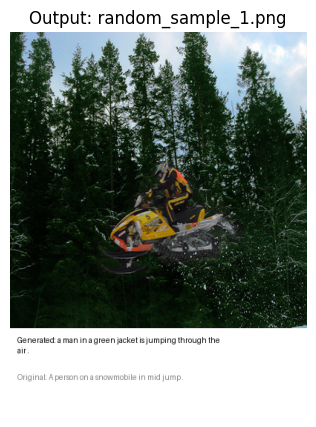

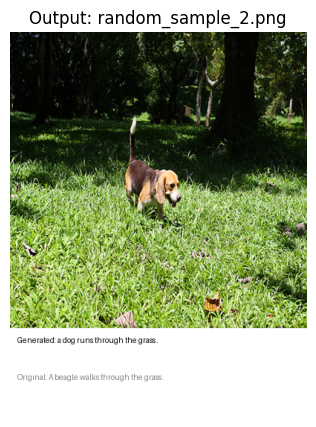

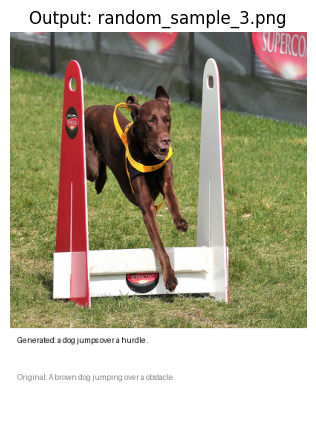

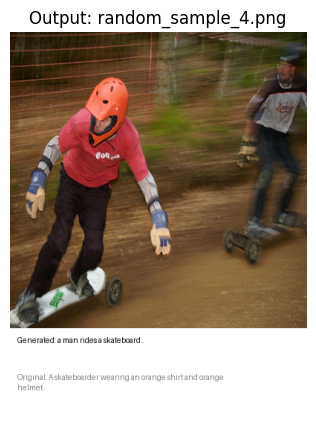

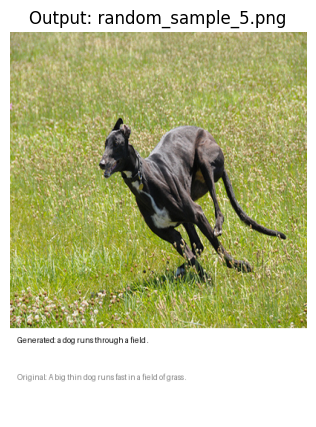

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# 1. Update the directory to match your new output folder
result_dir = Path("results/random_poster_samples")

# 2. Update the glob pattern to grab all images, since the names now
# likely match the original IDs (e.g., 109738763_90541ef30d.png)
# We search for both .png and .jpg just to be safe.
samples = sorted(list(result_dir.glob("*.png")) + list(result_dir.glob("*.jpg")))

print("Found sample files:", len(samples))

# 3. Plot the first 5 samples
for p in samples[:5]:
    img = Image.open(p)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Output: {p.name}")
    plt.show()

In [ ]:
import shutil
from pathlib import Path

backup_dir = Path("/content/drive/MyDrive/image-captioning-outputs")
backup_dir.mkdir(parents=True, exist_ok=True)

# Backup checkpoint
src_ckpt = Path("checkpoints/best_checkpoint.pth")
if src_ckpt.exists():
    shutil.copy2(src_ckpt, backup_dir / "best_checkpoint.pth")

# Backup results folder
src_results = Path("results")
dst_results = backup_dir / "results"
if src_results.exists():
    if dst_results.exists():
        shutil.rmtree(dst_results)
    shutil.copytree(src_results, dst_results)

print("Backup completed at:", backup_dir)

Backup completed at: /content/drive/MyDrive/image-captioning-outputs
